In [ ]:
!pip install scikit-learn pandas numpy nltk

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Load your dataset
df = pd.read_csv("/content/DataForTopicModelling.csv")   # Change the path

# Use combined text for modeling
docs = df["Combined"].fillna("").astype(str).tolist()

print("Total documents:", len(docs))
print("Example document:\n", docs[0][:300])

Total documents: 30
Example document:
 LLM4VV: Developing LLM-driven testsuite for compiler validation Large language models (LLMs) are a new and powerful tool for a wide span of applications involving natural and demonstrate impressive code generation abilities. The goal of this work is to automatically generate tests and use these test


In [ ]:
# stopwords useful for software engineering domain
custom_stopwords = set(stopwords.words("english"))
custom_stopwords.update([
    "software", "system", "systems", "approach", "paper", "study",
    "analysis", "model", "models", "ai", "artificial", "intelligence",
    "data", "development", "using", "used", "use", "tool", "tools",
    "llm", "llms", "large", "language", "models", "task", "tasks",
    "genai", "chatgpt", "copilot", "method", "methods"
])

def preprocess(text):
    text = text.lower()
    # Remove newlines & punctuation
    import re
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    return text

processed_docs = [preprocess(t) for t in docs]

In [ ]:
tfidf = TfidfVectorizer(
    max_df=0.85,       # ignore too-common words
    min_df=2,          # ignore rare words
    stop_words=list(custom_stopwords),
    ngram_range=(1,2)  # bigrams help reveal SDLC themes
)

X = tfidf.fit_transform(processed_docs)

In [ ]:
n_topics = 5   # you can change this (try 4, 5, or 6)

nmf = NMF(
    n_components=n_topics,
    random_state=42,
    max_iter=1000,
    init="nndsvda",
    alpha_W=0.0001,
    alpha_H=0.0001,
    l1_ratio=0.5
)

W = nmf.fit_transform(X)
H = nmf.components_
terms = tfidf.get_feature_names_out()

In [ ]:
def display_topics(H, terms, n_top_words=12):
    for topic_idx, topic in enumerate(H):
        print(f"\nTopic {topic_idx}:")
        print(", ".join([terms[i] for i in topic.argsort()[:-n_top_words-1:-1]]))

display_topics(H, terms, n_top_words=15)


Topic 0:
code, github, programming, generation, code generation, empirical, pair, source, programming languages, languages, quality, programmer, generated, solutions, correctness

Topic 1:
sdlc, lifecycle, roles, generative, phases, lifecycle sdlc, automation, gpt, skills, generative lifecycle, business, experts, sdlc automation, planning, deployment

Topic 2:
generative, practitioners, developer, productivity, engineering, gains, security, generative engineering, focusing, integration, coding, improve, improve developer, developer productivity, generative pair

Topic 3:
impact productivity, developers, productivity, impact, powered, find, pairprogramming, contributes, engage, github, insights, case, time, users, user

Topic 4:
engineering, adoption, developers, theory, technology, framework, understanding, review, innovation, generative, adoption engineering, integration, literature review, literature, optimize


In [ ]:
topic_labels = W.argmax(axis=1)
df["nmf_topic"] = topic_labels
df.to_csv("nmf_topic_output.csv", index=False)

df[["id","Title","Combined","nmf_topic"]].head(20)

,id,Title,Combined,nmf_topic
0,1,LLM4VV: Developing LLM-driven testsuite for co...,LLM4VV: Developing LLM-driven testsuite for co...,0
1,2,Accelerating Software Development Using Genera...,Accelerating Software Development Using Genera...,1
2,3,AI-Assisted Security: A Step towards Reimagini...,AI-Assisted Security: A Step towards Reimagini...,0
3,4,An Empirical Evaluation of GitHub Copilot’s Co...,An Empirical Evaluation of GitHub Copilot’s Co...,0
4,5,An Intelligent Hybrid GenAI Model for Software...,An Intelligent Hybrid GenAI Model for Software...,4
5,6,Assessing the Quality of GitHub Copilot’s Code...,Assessing the Quality of GitHub Copilot’s Code...,0
6,7,Copiloting the future: How generative AI trans...,Copiloting the future: How generative AI trans...,4
7,8,Cognitive Challenges in Human–Artificial Intel...,Cognitive Challenges in Human–Artificial Intel...,0
8,9,The Role of Generative AI in Software Developm...,The Role of Generative AI in Software Developm...,2
9,10,Generative AI for Software Practitioners,Generative AI for Software Practitioners,2


In [ ]:
manual_themes = {
    # ---- Stage-wise SDLC Themes ----
    "Requirements Engineering": ["requirement", "requirements engineering", "elicitation", "user story", "specification"],
    "Design": ["design", "architecture", "uml", "modeling", "blueprint"],
    "Implementation": ["implementation", "coding", "programming", "code", "refactoring"],
    "Testing": ["testing", "test", "debugging", "qa", "verification", "validation"],
    "Deployment": ["deployment", "deploy", "delivery", "pipeline", "ci cd"],
    "Maintenance": ["maintenance", "bug fixing", "evolution", "legacy"],

    # ---- Cross-sectional Themes ----
    "Adoption": ["adoption", "acceptance", "intention", "adopt"],
    "Organizational Readiness & Governance": ["governance", "organizational", "policy", "maturity", "compliance"],
    "Developer Productivity & Experience": ["productivity", "efficiency", "developer experience", "dx", "effort reduction"],
    "Workforce, Roles & Skill Evolution": ["workforce", "roles", "skills", "skill", "persona", "job"],
    "Human–AI Collaboration": ["collaboration", "pair programming", "ai assistant", "co creation", "copilot"],
    "Trust & Cognitive Effects": ["trust", "confidence", "cognitive", "mental load", "cognitive load"],
    "Security, Privacy & Ethical Concerns": ["security", "privacy", "ethical", "bias", "risk", "vulnerability", "ip"]
}


In [ ]:
# ==========================================================
# MAP TOPIC KEYWORDS → YOUR MANUAL THEMES
# ==========================================================

def map_to_manual(topic_keywords, manual):
    """
    topic_keywords: list of top words for the topic
    manual: manual themes dictionary
    """
    # join keywords into a single lowercase string
    text = " ".join(topic_keywords).lower()

    scores = {}
    for theme, keywords in manual.items():
        # count how many theme keywords appear in topic text
        score = sum(1 for kw in keywords if kw.lower() in text)
        scores[theme] = score

    # find highest matching theme
    best_theme = max(scores, key=scores.get)

    # if no match found
    if scores[best_theme] == 0:
        return "Other / No Strong Match"

    return best_theme

In [ ]:
# ==========================================================
# BUILD TABLE: topic_id → top keywords → mapped theme
# ==========================================================

mapped_topics = []

for idx, topic in enumerate(H):
    top_kws = [terms[i] for i in topic.argsort()[-10:]]  # top 10 words
    mapped_theme = map_to_manual(top_kws, manual_themes)
    mapped_topics.append((idx, top_kws, mapped_theme))

# Show the mapping table
mapped_topics

[(0,
  ['languages',
   'programming languages',
   'source',
   'pair',
   'empirical',
   'code generation',
   'generation',
   'programming',
   'github',
   'code'],
  'Implementation'),
 (1,
  ['generative lifecycle',
   'skills',
   'gpt',
   'automation',
   'lifecycle sdlc',
   'phases',
   'generative',
   'roles',
   'lifecycle',
   'sdlc'],
  'Workforce, Roles & Skill Evolution'),
 (2,
  ['integration',
   'focusing',
   'generative engineering',
   'security',
   'gains',
   'engineering',
   'productivity',
   'developer',
   'practitioners',
   'generative'],
  'Developer Productivity & Experience'),
 (3,
  ['github',
   'engage',
   'contributes',
   'pairprogramming',
   'find',
   'powered',
   'impact',
   'productivity',
   'developers',
   'impact productivity'],
  'Implementation'),
 (4,
  ['generative',
   'innovation',
   'review',
   'understanding',
   'framework',
   'technology',
   'theory',
   'developers',
   'adoption',
   'engineering'],
  'Adoption')]

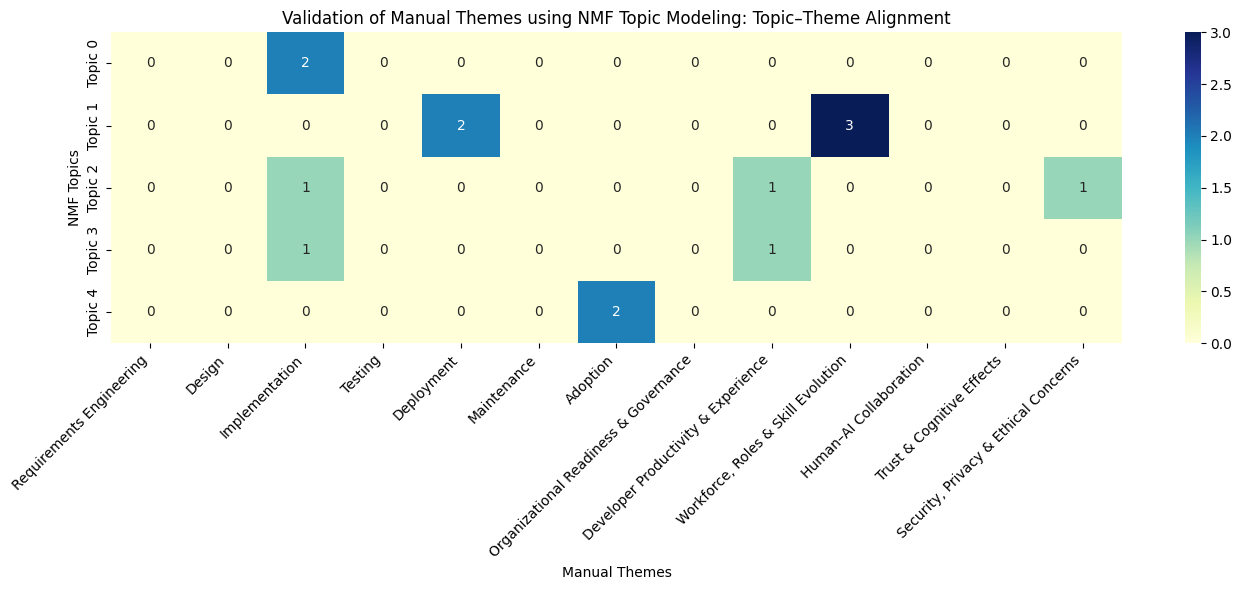

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ========================================================
# Build a topic-to-theme score matrix
# ========================================================

theme_list = list(manual_themes.keys())
topic_ids = list(range(len(H)))

# Initialize matrix
score_matrix = np.zeros((len(topic_ids), len(theme_list)))

for t_idx, topic in enumerate(H):
    top_kws = [terms[i] for i in topic.argsort()[-15:]]  # top 15 keywords
    text = " ".join(top_kws).lower()

    for j, theme in enumerate(theme_list):
        # count how many theme keywords appear in topic text
        score = sum(1 for kw in manual_themes[theme] if kw.lower() in text)
        score_matrix[t_idx, j] = score

# Convert to DataFrame for better plot control
heatmap_df = pd.DataFrame(score_matrix,
                          index=[f"Topic {i}" for i in topic_ids],
                          columns=theme_list)

# ========================================================
# Plot heatmap
# ========================================================

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", fmt="g")
plt.title("Validation of Manual Themes using NMF Topic Modeling: Topic–Theme Alignment")
plt.xlabel("Manual Themes")
plt.ylabel("NMF Topics")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
